In [1]:
from runner import run_coevolution_experiment
import numpy as np

solver_logs, maze_logs, final_best_theta, final_viz_envs, archive_snapshots, phase1_logs = run_coevolution_experiment()

[Init] Archive initialized with up to 200 mazes.
[Phase1] Picked 19 solvable mazes for initial solver training.
[Phase1 Gen 0] solver best=0.838, avg=0.216
[Phase1 Gen 5] solver best=0.861, avg=0.277
[Phase1 Gen 10] solver best=0.863, avg=0.269
[Phase1 Gen 15] solver best=0.893, avg=0.265
[Phase1 Gen 20] solver best=0.867, avg=0.270
[Phase1] Solver fitness written to archive.

[CoEV Gen 0]
  Solver: avg_steps=165.2, avg_rel=0.819, avg_base_steps=29.6
  Maze: avg_baseline_fit=87.6, avg_solver_fit=0.258

[CoEV Gen 1]
  Solver: avg_steps=72.6, avg_rel=0.739, avg_base_steps=27.0
  Maze: avg_baseline_fit=87.6, avg_solver_fit=0.249

[CoEV Gen 2]
  Solver: avg_steps=61.6, avg_rel=0.742, avg_base_steps=34.4
  Maze: avg_baseline_fit=87.6, avg_solver_fit=0.255

[CoEV Gen 3]
  Solver: avg_steps=121.2, avg_rel=0.718, avg_base_steps=27.0
  Maze: avg_baseline_fit=87.6, avg_solver_fit=0.111

[CoEV Gen 4]
  Solver: avg_steps=50.4, avg_rel=0.655, avg_base_steps=30.3
  Maze: avg_baseline_fit=87.6, avg_s

1. Solver fitness

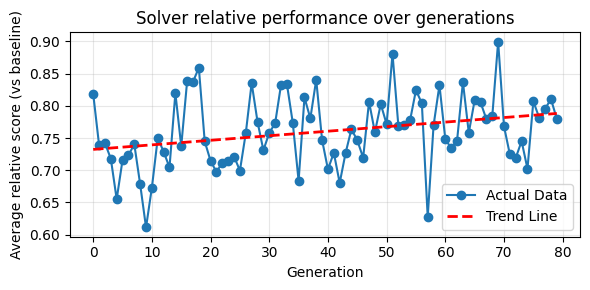

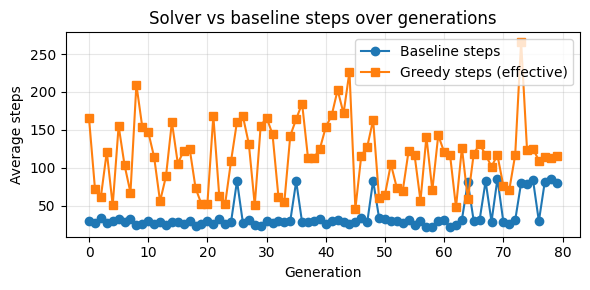

In [8]:
import matplotlib.pyplot as plt

gens = [log["gen"] for log in solver_logs]
avg_rel = [log["avg_rel"] for log in solver_logs]
avg_solver_steps = [log["avg_solver_steps"] for log in solver_logs]
avg_baseline_steps = [log["avg_baseline_steps"] for log in solver_logs]

# ----- rel performance（solver vs baseline） -----
plt.figure(figsize=(6, 3))
plt.plot(gens, avg_rel, marker="o", label="Actual Data")
if len(gens) > 1:
    z = np.polyfit(gens, avg_rel, 1)
    p = np.poly1d(z)
    plt.plot(gens, p(gens), "r--", linewidth=2, label="Trend Line")

plt.xlabel("Generation")
plt.ylabel("Average relative score (vs baseline)")
plt.title("Solver relative performance over generations")
plt.grid(True, alpha=0.3)
plt.legend() 

plt.tight_layout()
plt.show()

# ----- steps comparasion -----
plt.figure(figsize=(6, 3))
plt.plot(gens, avg_baseline_steps, label="Baseline steps", marker="o")
plt.plot(gens, avg_solver_steps, label="Greedy steps (effective)", marker="s")
plt.xlabel("Generation")
plt.ylabel("Average steps")
plt.title("Solver vs baseline steps over generations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Phase 1 fitness:

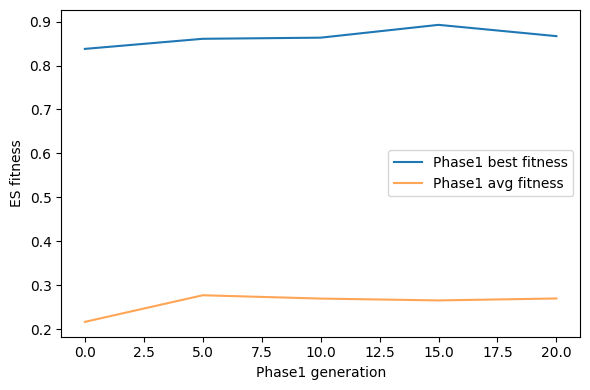

In [3]:
gens = np.array(phase1_logs["gen"])
best_fit = np.array(phase1_logs["best_fit"])
avg_fit  = np.array(phase1_logs["avg_fit"])

plt.figure(figsize=(6,4))
plt.plot(gens, best_fit, label="Phase1 best fitness")
plt.plot(gens, avg_fit,  label="Phase1 avg fitness", alpha=0.7)
plt.xlabel("Phase1 generation")
plt.ylabel("ES fitness")
plt.legend()
plt.tight_layout()
plt.show()

2. Maze fitness

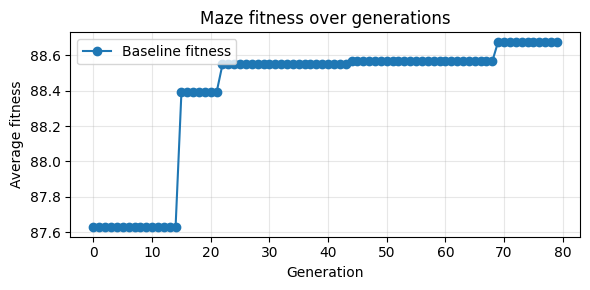

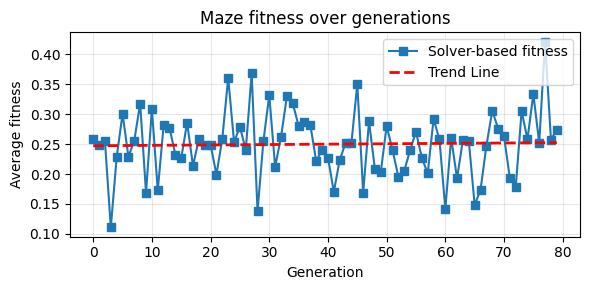

In [9]:
maze_gens = [log["gen"] for log in maze_logs]
avg_base_fit = [log["avg_baseline_fitness"] for log in maze_logs]
avg_solver_fit = [log["avg_solver_fitness"] for log in maze_logs]

plt.figure(figsize=(6, 3))
plt.plot(maze_gens, avg_base_fit, label="Baseline fitness", marker="o")
# plt.plot(maze_gens, avg_solver_fit, label="Solver-based fitness", marker="s")
plt.xlabel("Generation")
plt.ylabel("Average fitness")
plt.title("Maze fitness over generations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
# plt.plot(maze_gens, avg_base_fit, label="Baseline fitness", marker="o")
plt.plot(maze_gens, avg_solver_fit, label="Solver-based fitness", marker="s")
if len(maze_gens) > 1:
    z = np.polyfit(maze_gens, avg_solver_fit, 1)
    p = np.poly1d(z)
    plt.plot(maze_gens, p(maze_gens), "r--", linewidth=2, label="Trend Line")

plt.xlabel("Generation")
plt.ylabel("Average fitness")
plt.title("Maze fitness over generations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


3. Final Mazes

In [5]:
from Maze.Maze import Maze
for i, indiv in enumerate(final_viz_envs):
    print(f"\n=== Maze {i} ===")
    maze = Maze(indiv.genome)
    print(maze.to_ascii())
    print("Start:", maze.start, "Goal:", maze.goal)


=== Maze 0 ===
████████████████
█         █G  ██
█ ███████ █ ████
█   █   █ █   ██
█████S█ █□███ ██
█     █ █     ██
█ █████ █████ ██
█     █   █   ██
█████ ███ █ ████
█     █   █   ██
█ ███████████ ██
█     █     █ ██
█ ███ █ ███ █ ██
█   █     █   ██
████████████████
████████████████
Start: (4, 5) Goal: (1, 11)

=== Maze 1 ===
████████████████
█ █     █   █ ██
█ █ ███ █ █ █ ██
█   █   █ █ █ ██
█████ ███ █ █ ██
█     █   █ █ ██
█G███████ █ █ ██
█       █ █ █ ██
███████ █ █ █ ██
█     █ █ █   ██
█ █████ █ ███□██
█ █     █ █   ██
█ █ █████ █ ████
█  S      █   ██
████████████████
████████████████
Start: (13, 3) Goal: (6, 1)

=== Maze 2 ===
████████████████
█   █   █   █ ██
█ ███ ███ █ █ ██
█S    █   █□  ██
█ █████ █████ ██
█ █     █     ██
█ █ █████ ██████
█ █     █ █   ██
█ █ ███ █ █ █ ██
█ █   █ █ █ █ ██
█ █ ███ █ █G█ ██
█ █ █   █   █ ██
█ ███ ███████ ██
█     █       ██
████████████████
████████████████
Start: (3, 1) Goal: (10, 11)

=== Maze 3 ===
████████████████
█       █   S ██
█

4. Feature Map

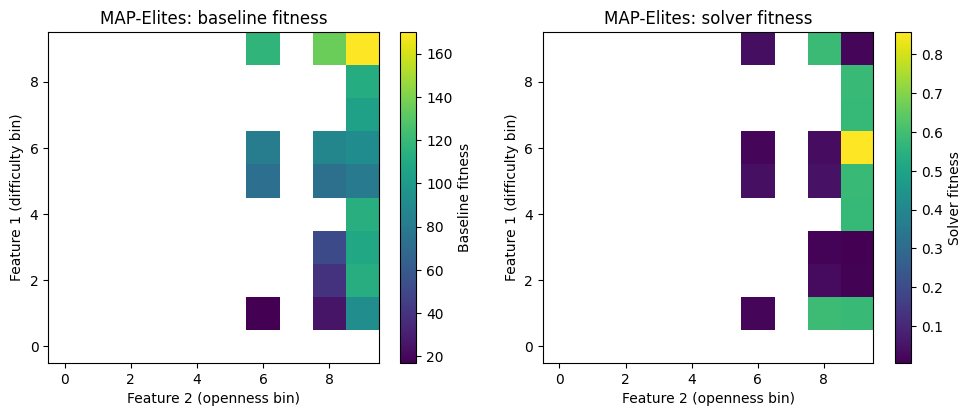

In [6]:
last_archive = archive_snapshots[-1]


snap = last_archive
cells = snap["cells"]

n_rows = max(c["row"] for c in cells) + 1
n_cols = max(c["col"] for c in cells) + 1

baseline_grid = np.full((n_rows, n_cols), np.nan)
solver_grid   = np.full((n_rows, n_cols), np.nan)

for c in cells:
    r = c["row"]
    co = c["col"]
    baseline_grid[r, co] = c["baseline_fitness"]
    solver_grid[r, co]   = c["solver_fitness"]


vmin = np.nanmin(baseline_grid)
vmax = np.nanmax(baseline_grid)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    baseline_grid,
    origin="lower",
    cmap="viridis",
)
plt.colorbar(label="Baseline fitness")
plt.xlabel("Feature 2 (openness bin)")
plt.ylabel("Feature 1 (difficulty bin)")
plt.title("MAP-Elites: baseline fitness")

plt.subplot(1, 2, 2)
plt.imshow(
    solver_grid,
    origin="lower",
    cmap="viridis",
)
plt.colorbar(label="Solver fitness")
plt.xlabel("Feature 2 (openness bin)")
plt.ylabel("Feature 1 (difficulty bin)")
plt.title("MAP-Elites: solver fitness")

plt.tight_layout()
plt.show()
